# Global landscape features

Illustrates MOLA's **global** landscape features (paper §4.1.1, Table 1) — the one class that does not depend on the neighbourhood graph. Each section below pairs a feature's definition with a small, real, *executed* example built on `mola`'s own code, not hand-typed numbers: if the implementation ever changes, re-running this notebook is the check.

Built incrementally — one section is added per feature, in the same commit that implements it (see `CLAUDE.md`'s "Feature implementation matrix"). As of this notebook, only `dist_x_avg` exists.

## `dist_x_avg` — average distance among solutions in variable space

> "the average and maximum distance among sampled solutions in the variable space" (§4.1.1)

Computed as the mean Euclidean distance over every pair of sampled solutions in **decision** space, then max-min normalized against that *same sample's own* pairwise-distance range (Design decisions, "Normalization reference") — never against the search-space bounds, and never recomputed over a subset.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mola.distance import pairwise_distance_stats
from mola.features import dist_x_avg
from mola.normalization import Normalizer

# Three 2-D toy samples, deliberately built to have very different shapes:
rng = np.random.default_rng(seed=0)
samples = {
    "spread": rng.uniform(low=0.0, high=10.0, size=(15, 2)),
    "clustered": rng.normal(loc=(5.0, 5.0), scale=0.3, size=(15, 2)),
}
cluster_core = rng.normal(loc=(5.0, 5.0), scale=0.3, size=(14, 2))
samples["with_outlier"] = np.vstack([cluster_core, [[20.0, 20.0]]])

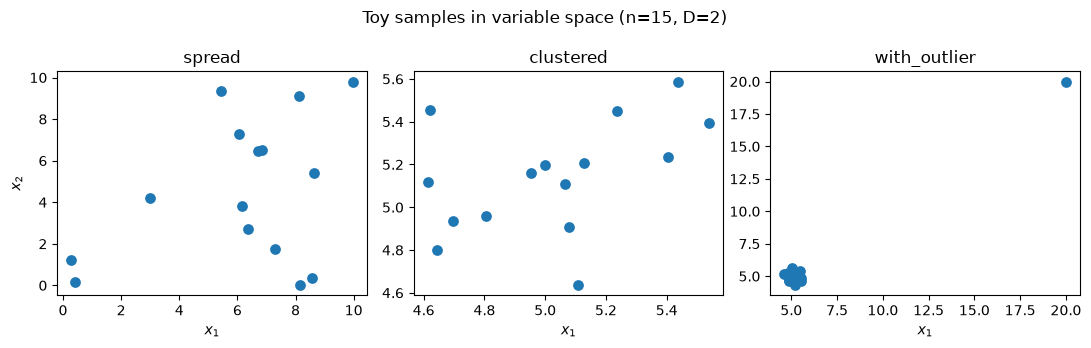

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharex=False, sharey=False)
for ax, (label, points) in zip(axes, samples.items(), strict=True):
    ax.scatter(points[:, 0], points[:, 1], s=45)
    ax.set_title(label)
    ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
fig.suptitle("Toy samples in variable space (n=15, D=2)")
fig.tight_layout()
plt.show()

In [3]:
for label, points in samples.items():
    stats = pairwise_distance_stats(points)
    normalizer = Normalizer(minimum=stats.minimum, maximum=stats.maximum)
    value = dist_x_avg(points, normalizer)
    print(
        f"{label:13s} raw range=[{stats.minimum:6.3f}, {stats.maximum:6.3f}]"
        f"  raw mean={stats.mean:6.3f}   dist_x_avg={value:.3f}"
    )

spread        raw range=[ 0.153, 13.580]  raw mean= 5.665   dist_x_avg=0.411
clustered     raw range=[ 0.058,  1.117]  raw mean= 0.511   dist_x_avg=0.428
with_outlier  raw range=[ 0.029, 21.555]  raw mean= 3.338   dist_x_avg=0.154


**Reading the numbers above.** `Normalizer` is always fixed to *this sample's own* pairwise-distance range, never a global or search-space bound — so `dist_x_avg` is not a cross-sample-comparable measure of "how spread out" a sample is. `spread` and `clustered` land on nearly the same value despite an order-of-magnitude difference in absolute scale: both have a roughly uniform *shape* of pairwise distances relative to their own range. `with_outlier` scores far lower: most pairs sit close together inside the tight cluster, and only the few pairs touching the outlier stretch the range, pulling the *mean* down toward the *minimum*. `dist_x_avg` captures that shape, not the absolute scale.

## `dist_x_max` — maximum distance among solutions in variable space

> "the average and maximum distance among sampled solutions in the variable space" (§4.1.1)

The counterpart to `dist_x_avg`, over the same pairwise distances — but reported **raw**, never normalized (every `*_MAX` feature stays raw). Reusing the three samples above makes the contrast with `dist_x_avg` explicit: the *raw* maximum differs by an order of magnitude between `spread` and `clustered` — exactly the difference `dist_x_avg`'s per-sample normalization hides.

In [4]:
from mola.features import dist_x_max

for label, points in samples.items():
    value = dist_x_max(points)
    print(f"{label:13s} dist_x_max={value:.3f}")

spread        dist_x_max=13.580
clustered     dist_x_max=1.117
with_outlier  dist_x_max=21.555


## `dist_f_max` — maximum distance among solutions in objective space

> "the average and maximum distance among sampled solutions in the objective space" (§4.1.1)

Same statistic as `dist_x_max`, computed over **objective** vectors instead of decision vectors — `pairwise_distance_stats` doesn't care which space it's given, only that it's handed points. Also raw, never normalized. The toy front below deliberately includes one dominated solution (`F`): `dist_f_max` runs over the whole sample, not just the non-dominated subset — that restriction is what `dist_x_nd_max` (not yet implemented) will add.

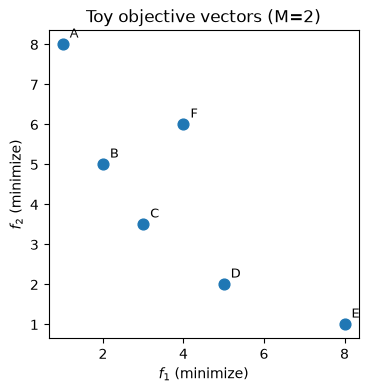

dist_f_max = 9.899


In [5]:
from mola.features import dist_f_max

objectives = np.array(
    [
        [1.0, 8.0],
        [2.0, 5.0],
        [3.0, 3.5],
        [5.0, 2.0],
        [8.0, 1.0],
        [4.0, 6.0],
    ]
)
labels = list("ABCDEF")

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(objectives[:, 0], objectives[:, 1], s=60)
for label, (f1, f2) in zip(labels, objectives, strict=True):
    ax.annotate(label, (f1, f2), textcoords="offset points", xytext=(5, 5), fontsize=9)
ax.set_xlabel("$f_1$ (minimize)")
ax.set_ylabel("$f_2$ (minimize)")
ax.set_title("Toy objective vectors (M=2)")
plt.show()

print(f"dist_f_max = {dist_f_max(objectives):.3f}")

## `nd_n` — proportion of non-dominated solutions

> "the proportion of non-dominated solutions" (§4.1.1)

The first feature here that needs the ranking substrate: `mola.ranking.rank_solutions` wraps jMetalPy's `FastNonDominatedRanking` rather than reimplementing dominance sorting — deliberately, since ad hoc reimplementation of exactly this logic is what shipped several of MOORPHOLOGY's silent bugs. `nd_n` is simply the size of the first front (rank 0) over the sample size.

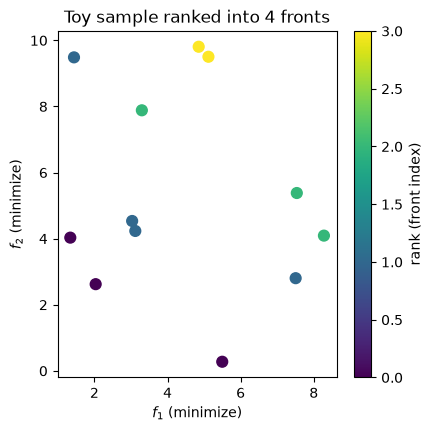

nd_n = 0.250  (3 of 12 solutions)


In [6]:
from mola.features import nd_n
from mola.ranking import rank_solutions

front_rng = np.random.default_rng(seed=1)
objectives = front_rng.uniform(low=0.0, high=10.0, size=(12, 2))
ranking = rank_solutions(objectives)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
scatter = ax.scatter(objectives[:, 0], objectives[:, 1], c=ranking.rank, cmap="viridis", s=60)
fig.colorbar(scatter, ax=ax, label="rank (front index)")
ax.set_xlabel("$f_1$ (minimize)")
ax.set_ylabel("$f_2$ (minimize)")
ax.set_title(f"Toy sample ranked into {ranking.number_of_fronts} fronts")
plt.show()

print(f"nd_n = {nd_n(ranking):.3f}  ({ranking.nondominated.size} of {ranking.rank.size} solutions)")

## `rank_avg` — average rank with respect to non-dominated sorting

> "the average... rank" (§4.1.1)

Reuses the exact same `ranking` computed above — no new sorting, just a different statistic of the same per-solution rank array (rank 0 = non-dominated, per `mola.ranking`'s own convention).

In [7]:
from mola.features import rank_avg

print(f"per-solution ranks: {ranking.rank.tolist()}")
print(f"rank_avg = {rank_avg(ranking):.3f}")

per-solution ranks: [3, 1, 1, 2, 0, 2, 2, 1, 0, 0, 1, 3]
rank_avg = 1.333


## `rank_max` — maximum rank with respect to non-dominated sorting

> "the average and maximum... rank" (§4.1.1)

Reuses the same `ranking` from the `nd_n` section above -- the largest per-solution rank, equivalently `ranking.number_of_fronts - 1`.

In [8]:
from mola.features import rank_max

print(f"rank_max = {rank_max(ranking):.3f}")

rank_max = 3.000


## `rank_ent` — entropy of the distribution of solutions per rank

> "the entropy of the distribution of the number of solutions per rank" (§4.1.1)

Shannon entropy, base 2, of the front-size proportions -- the paper doesn't state a log base; this matches MOORPHOLOGY's `getRankEntropy` exactly, confirmed by reading its source rather than assumed. Zero bits means every solution landed in one front (no surprise in which front a solution falls into); it grows toward its maximum as the fronts become more even in size.

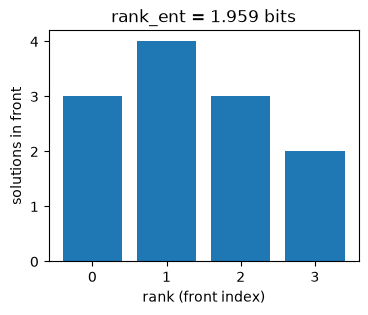

front sizes: [3, 4, 3, 2]


In [9]:
from mola.features import rank_ent

front_sizes = [front.size for front in ranking.fronts]

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(range(len(front_sizes)), front_sizes)
ax.set_xlabel("rank (front index)")
ax.set_ylabel("solutions in front")
ax.set_xticks(range(len(front_sizes)))
ax.set_title(f"rank_ent = {rank_ent(ranking):.3f} bits")
plt.show()

print(f"front sizes: {front_sizes}")

## `f_cor` — correlation among objective values

> "the (Spearman) correlation among the objective values measured on the sample" (§4.1.1)

A negative `f_cor` is a real signal: the objectives genuinely conflict (improving one tends to worsen the other), which is exactly what makes the problem multi-objective in the first place. A positive value means the objectives are redundant -- solving one tends to solve the other too. **MOLA's own extension**, beyond the paper's bi-objective benchmark: for M>2, the mean of the C(M,2) pairwise Spearman correlations, signed, not `abs()` (Design decisions).

In [10]:
from mola.features import f_cor

# The same A-E trade-off curve from the dist_f_max section above (`objectives` has since
# been reassigned by the nd_n section, so it's rebuilt explicitly here rather than
# reused): a genuine conflicting-objectives front, improving f_1 worsens f_2.
conflicting = np.array([[1.0, 8.0], [2.0, 5.0], [3.0, 3.5], [5.0, 2.0], [8.0, 1.0]])
redundant = np.array([[1.0, 2.0], [2.0, 4.0], [3.0, 5.0], [5.0, 9.0], [8.0, 15.0]])

print(f"f_cor (conflicting objectives) = {f_cor(conflicting):.3f}")
print(f"f_cor (redundant objectives)   = {f_cor(redundant):.3f}")

f_cor (conflicting objectives) = -1.000
f_cor (redundant objectives)   = 1.000


## `dist_x_nd_max` — maximum distance among non-dominated solutions in variable space

> "the average and maximum distance among non-dominated solutions in the variable space" (§4.1.1)

Reported raw, like every other `*_MAX` feature. MOORPHOLOGY's equivalent has a pair-filter bug -- it checks a sample index against *itself*, not against the other member of the pair -- so a dominated solution can silently leak into what's supposed to be a non-dominated-only computation. Reusing the A-F toy front (rebuilt explicitly, same values as the `dist_f_max` section) makes this concrete: giving the dominated point `F` a deliberately extreme variable-space position shows it excluded from the maximum below.

In [11]:
from mola.features import dist_x_nd_max
from mola.ranking import rank_solutions

# Same A-F objectives as the dist_f_max section (F dominated by C).
front_objectives = np.array(
    [[1.0, 8.0], [2.0, 5.0], [3.0, 3.5], [5.0, 2.0], [8.0, 1.0], [4.0, 6.0]]
)
front_labels = list("ABCDEF")
# A, B, C, D, E, F in variable space -- F (dominated) placed far out on purpose.
front_variables = np.array([[0.0], [2.0], [4.0], [7.0], [11.0], [16.0]])
front_ranking = rank_solutions(front_objectives)

non_dominated_labels = [front_labels[i] for i in front_ranking.nondominated]
print(f"non-dominated: {non_dominated_labels}")
print(f"dist_x_nd_max = {dist_x_nd_max(front_variables, front_ranking):.3f}")

non-dominated: ['A', 'B', 'C', 'D', 'E']
dist_x_nd_max = 11.000


## `dist_x_nd_avg`, `dist_f_avg` — average distance, non-dominated / objective space

> "the average and maximum distance among non-dominated solutions in the variable space" / "...among sampled solutions in the objective space" (§4.1.1)

`dist_x_nd_avg` is `dist_x_nd_max`'s normalized sibling — same non-dominated subset (`front_ranking.nondominated` from the section above), same fix for MOORPHOLOGY's pair-filter bug, plus its wrong-divisor half (a per-solution count instead of a pair count). `dist_f_avg` reuses the A-F toy front's objectives directly: MOORPHOLOGY's bug here was normalizing objective-space distance with a variable-space-derived minimum -- using the correctly-sourced `Normalizers.objective_space` here rules that out by construction.

In [12]:
from mola.features import dist_f_avg, dist_x_nd_avg
from mola.normalization import build_normalizers

front_normalizers = build_normalizers(front_variables, front_objectives)

print(
    f"dist_x_nd_avg = "
    f"{dist_x_nd_avg(front_variables, front_ranking, front_normalizers.variable_space):.3f}"
)
print(f"dist_f_avg    = {dist_f_avg(front_objectives, front_normalizers.objective_space):.3f}")

dist_x_nd_avg = 0.243
dist_f_avg    = 0.344


## `fdc` — fitness-distance correlation

> "the (Spearman) correlation between the distance among [non-dominated solutions] in the variable space vs. in the objective space" (§4.1.1)

Correlates *pairwise* variable-space and objective-space distance over the non-dominated subset — distinct from `dist_x_cor_neig`/`dist_f_cor_neig` (a per-solution *average*-distance-to-*neighbours* measure over the whole sample) and from `dist_f_dist_x_avg_neig` (a ratio, not a correlation). A high `fdc` means variable-space distance is a good proxy for objective-space distance among the non-dominated front — a smoothly-varying trade-off surface; a low or negative one means the mapping is more erratic.

In [13]:
from mola.features import fdc

print(f"fdc = {fdc(front_variables, front_objectives, front_ranking):.3f}")

fdc = 0.932
